In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
#Load the data from the dataset
dataset = 'gene_expression_disease_classification.csv'
#Create a dataframe (df)
df = pd.read_csv(dataset)
print(df)

        GENE_1    GENE_2    GENE_3    GENE_4    GENE_5    GENE_6    GENE_7  \
0     0.496714 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1    -1.907808 -0.860385 -0.413606  1.887688  0.556553 -1.335482  0.486036   
2    -1.114081 -0.630931 -0.942060 -0.547996 -0.214150  0.837154 -0.321159   
3     0.765402  1.073413  0.498690 -1.942498 -0.155422 -1.155708 -0.202606   
4     1.174814 -1.878981 -0.327795 -0.041660  0.015909  0.180496  0.610440   
...        ...       ...       ...       ...       ...       ...       ...   
1995  0.039025 -0.120973 -1.552823 -0.893826 -0.425615  0.688815 -0.146257   
1996  0.594503 -0.257436  0.888427  1.223201 -0.999601  1.158148 -0.858107   
1997  0.186930 -1.054081 -1.170749 -0.133086  1.192664  1.355714  0.644261   
1998 -0.505850  0.484309 -0.641611  1.151560 -0.212056 -0.448942 -0.410674   
1999 -0.054481 -0.202532 -1.815711 -0.783824 -0.925776 -0.976697  0.200945   

        GENE_8    GENE_9   GENE_10  ...  GENE_2992  GENE_2993  

In [3]:
# Data cleaning
print("Dupe:", df.duplicated().sum()) # No duplicate data, cleaning not needed
print("NA:", df.isna().sum().sum()) # No empty data, cleaning not needed

Dupe: 0
NA: 0


Standard deviation range: 1.7956052041900885 , 0.9423068100619046
Corresponding respectively to: GENE_1455 , GENE_2342
p value for GENE_1
0.38398232396221427
Likely normal


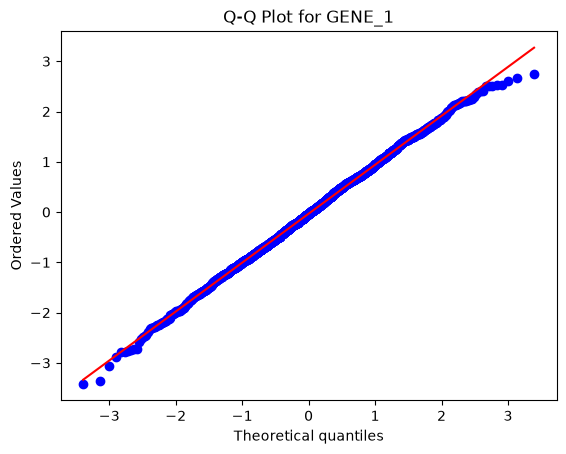

Data is likely normally distributed (diagonal q-q for all 4 plots)
p value for GENE_1000
0.6024049393462347
Likely normal


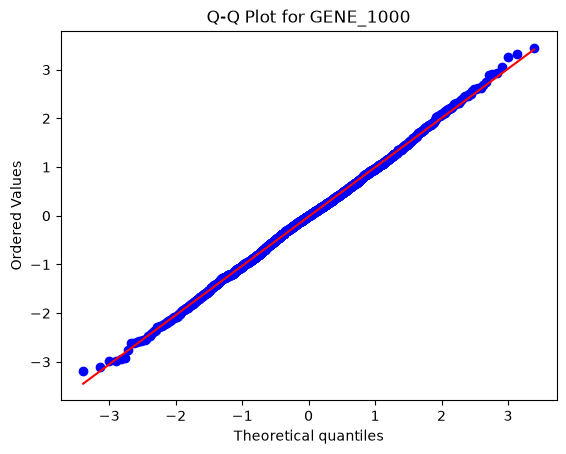

Data is likely normally distributed (diagonal q-q for all 4 plots)
p value for GENE_2000
0.710150263012945
Likely normal


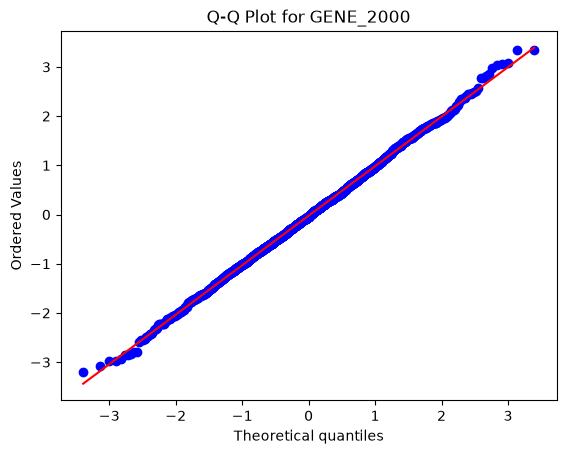

Data is likely normally distributed (diagonal q-q for all 4 plots)
p value for GENE_3000
0.802064040960069
Likely normal


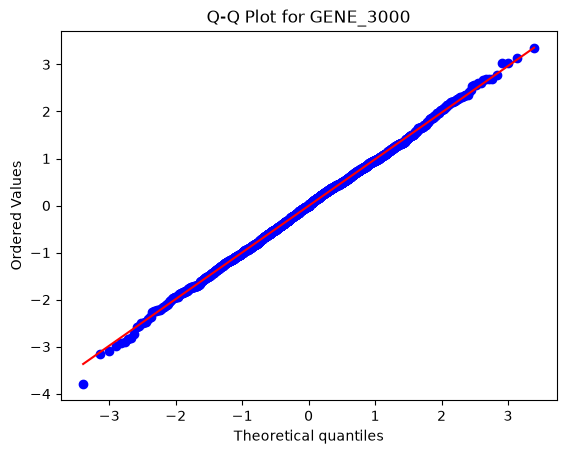

Data is likely normally distributed (diagonal q-q for all 4 plots)


In [4]:
# Basic info
desc = df.describe()
desc = desc.drop("disease_label", axis='columns')
print("Standard deviation range:", desc.iloc[2].max(), ",", desc.iloc[2].min())
print("Corresponding respectively to:", desc.idxmax(1)["std"], ",", desc.idxmin(1)["std"])
for i in ["GENE_1", "GENE_1000", "GENE_2000", "GENE_3000"]: 
    print("p value for " + i)
    print(stats.normaltest(df[i])[1])
    if (stats.normaltest(df[i])[1] > 0.05):
        print("Likely normal")
    stats.probplot(df[i], dist="norm", plot=plt) # Alternatively, using q-q plots
    plt.title("Q-Q Plot for " + i) 
    plt.show()
    print("Data is likely normally distributed (diagonal q-q for all 4 plots)")

In [5]:
# Identify candidate genes (BH adjusted p-value < 0.05)
group1 = df.iloc[df["disease_label"] == 1][0:2999]
group1 = group1.drop("disease_label", axis="columns")
group0 = df.iloc[df["disease_label"] == 0][0:2999]
group0 = group0.drop("disease_label", axis="columns")

p_values = stats.ttest_ind(group1, group0).pvalue # Test for deviation of disease from healthy
reject = multipletests(p_values, method="fdr_bh")[0] # Corrects for false positives from multiple tests
results = pd.DataFrame(index=desc.columns)
results["Reject"] = reject

In [6]:
# Filter genes for further research (95% confidence intervals do not overlap)
sem1 = group1.sem()
sem0 = group0.sem()
mean1 = group1.mean()
mean0 = group0.mean()

ci_low1  = mean1 - 1.96 * sem1 # 1.96 from z-table (large sample size >>30 in each group despite unknown/estimated std)
ci_high1 = mean1 + 1.96 * sem1
ci_low0  = mean0 - 1.96 * sem0
ci_high0 = mean0 + 1.96 * sem0

overlap = (ci_high1 >= ci_low0) & (ci_high0 >= ci_low1)
results["CI_Overlap"] = overlap
results["mean_diseased"] = mean1
results["mean_healthy"] = mean0
results["ci_low_diseased"] = ci_low1
results["ci_high_diseased"] = ci_high1
results["ci_low_healthy"] = ci_low0
results["ci_high_healthy"] =ci_high0

In [7]:
# Results
print("Genes with adjusted p-values of <0.05 and no confidence interval overlap between disease and healthy groups.")
result_genes = results[results["Reject"] * ~results["CI_Overlap"]]
print(result_genes.index)
print(len(result_genes))

Genes with adjusted p-values of <0.05 and no confidence interval overlap between disease and healthy groups.
Index(['GENE_50', 'GENE_104', 'GENE_163', 'GENE_173', 'GENE_205', 'GENE_363',
       'GENE_405', 'GENE_437', 'GENE_461', 'GENE_481', 'GENE_526', 'GENE_691',
       'GENE_733', 'GENE_748', 'GENE_917', 'GENE_975', 'GENE_1047',
       'GENE_1057', 'GENE_1138', 'GENE_1173', 'GENE_1207', 'GENE_1341',
       'GENE_1364', 'GENE_1410', 'GENE_1455', 'GENE_1541', 'GENE_1577',
       'GENE_1588', 'GENE_1633', 'GENE_1657', 'GENE_1690', 'GENE_1760',
       'GENE_1853', 'GENE_1891', 'GENE_1978', 'GENE_2019', 'GENE_2038',
       'GENE_2124', 'GENE_2125', 'GENE_2198', 'GENE_2278', 'GENE_2392',
       'GENE_2398', 'GENE_2454', 'GENE_2690', 'GENE_2768', 'GENE_2795',
       'GENE_2866', 'GENE_2890', 'GENE_2975', 'GENE_2994'],
      dtype='str')
51


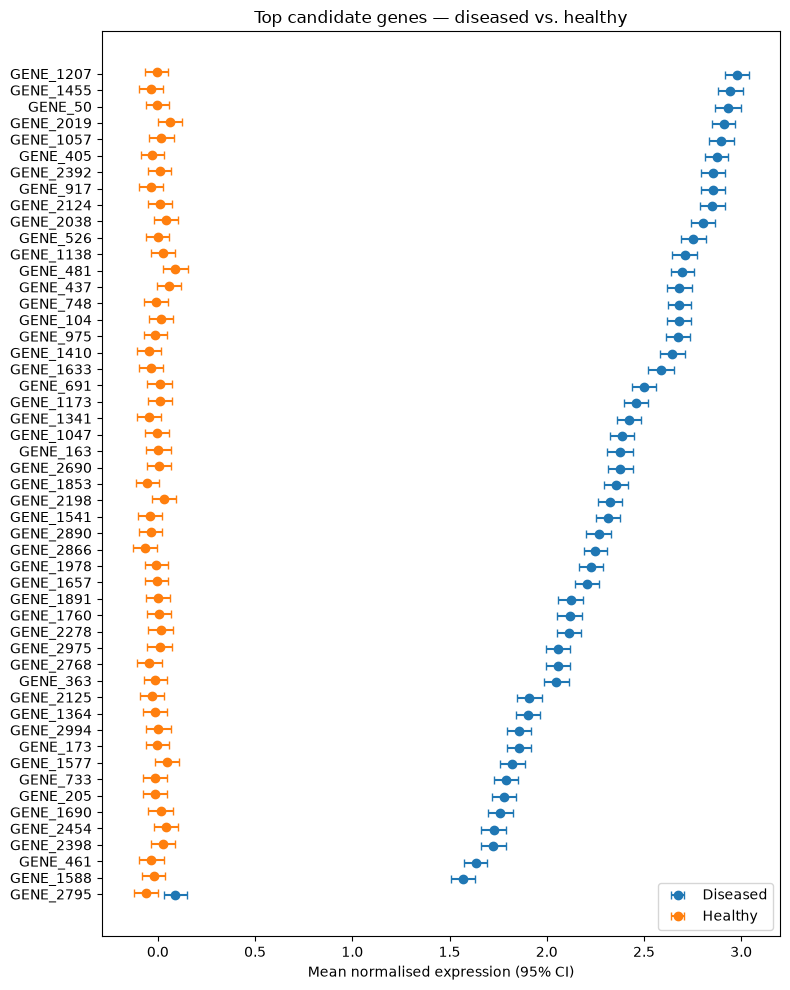

GENE_2795 passed DH-adjusted significance and CI criteria but showed a substantially smaller extent of overexpression compared to the other 50 genes. It is likely not biologically significant for further studies.
Only overexpression of disease genes is found in this fictitious study. In a real study, underexpression of genes is also expected.


In [8]:
# Forest graph data presentation and analysis
sort = result_genes.sort_values("mean_diseased", ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))

y = np.arange(len(sort))

# Diseased
ax.errorbar(
    sort["mean_diseased"], y,
    xerr=[sort["mean_diseased"] - sort["ci_low_diseased"], # Top of error bar (ci_high)
          sort["ci_high_diseased"] - sort["mean_diseased"]], # Bottom of error bar (ci_low)
    fmt="o", color="tab:blue", label="Diseased", capsize=3
)

# Healthy
ax.errorbar(
    sort["mean_healthy"], y + 0.15,
    xerr=[sort["mean_healthy"] - sort["ci_low_healthy"],
          sort["ci_high_healthy"] - sort["mean_healthy"]],
    fmt="o", color="tab:orange", label="Healthy", capsize=3
)

ax.set_yticks(y + 0.075)
ax.set_yticklabels(sort.index)
ax.set_xlabel("Mean normalised expression (95% CI)")
ax.set_title("Top candidate genes — diseased vs. healthy")
ax.legend()
# plt.savefig("forest_plot.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()
print("GENE_2795 passed DH-adjusted significance and CI criteria but showed a substantially smaller extent of overexpression compared to the other 50 genes. It is likely not biologically significant for further studies.")
print("Only overexpression of disease genes is found in this fictitious study. In a real study, underexpression of genes is also expected.")